In [12]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision.transforms import transforms as T
from IPython.display import clear_output
import matplotlib.pyplot as plt
import torch.optim as optim
from PIL import Image
from glob import glob
import os

In [19]:
def _loader(path: str) -> Image.Image:
    with open(path, 'rb') as f:
        img = Image.open(f)
        return img.convert('L') # конвертируем в grayscale - черно-белый формат

class Faces(Dataset):
    def __init__(self, root: str, split: str = 'train', transform = None):
        self.root = os.path.join(root, split)
        self.names, self.name2idx, self.idx2name = self._get_names()

        self.images, self.labels = self._get_people()
        self.total_idxs = len(self.images)

        self.transform = transform

    def _get_names(self):
        names = list(map(lambda x: int(x), os.listdir(self.root))) # список всех файлов в папке root (в виде чисел)

        name2idx = {name: _ for _, name in enumerate(names)}
        idx2name = {_: name for _, name in enumerate(names)}

        return names, name2idx, idx2name

    def _get_people(self):
        # все пути до фотографий
        images = glob(os.path.join(self.root, '*/*'))
        # получим номер папки с картинками конкретного человека
        labels = [self.name2idx[int(image.split('\\')[-2])] for image in images]

        return np.asarray(images), np.asarray(labels)

    def __getitem__(self, item):
        # как мы будем выбирать картинки для обучения
        # первая по индексу
        image1 = _loader(self.images[item])
        # вторая в 50% случаев - того же человека
        if np.random.uniform() < 0.5:
            image2 = _loader(np.random.choice(self.images[self.labels == self.labels[item]]))
            label = torch.tensor([1], dtype = torch.float32)
        # иначе - другого человека
        else:
            image2 = _loader(np.random.choice(self.images[self.labels != self.labels[item]]))
            label = torch.tensor([0], dtype = torch.float32)
        
        if self.transform is not None:
            image1 = self.transform(image1)
            image2 = self.transform(image2)
        
        return image1, image2, label, torch.tensor([self.labels[item]], dtype = torch.int)

    def __len__(self):
        return len(self.images)
        

In [20]:
dataset = Faces('faces_dataset')

In [34]:
dataset[2]

(<PIL.Image.Image image mode=L size=92x112>,
 <PIL.Image.Image image mode=L size=92x112>,
 tensor([1.]),
 tensor([0], dtype=torch.int32))

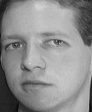

In [37]:
dataset[2][0]

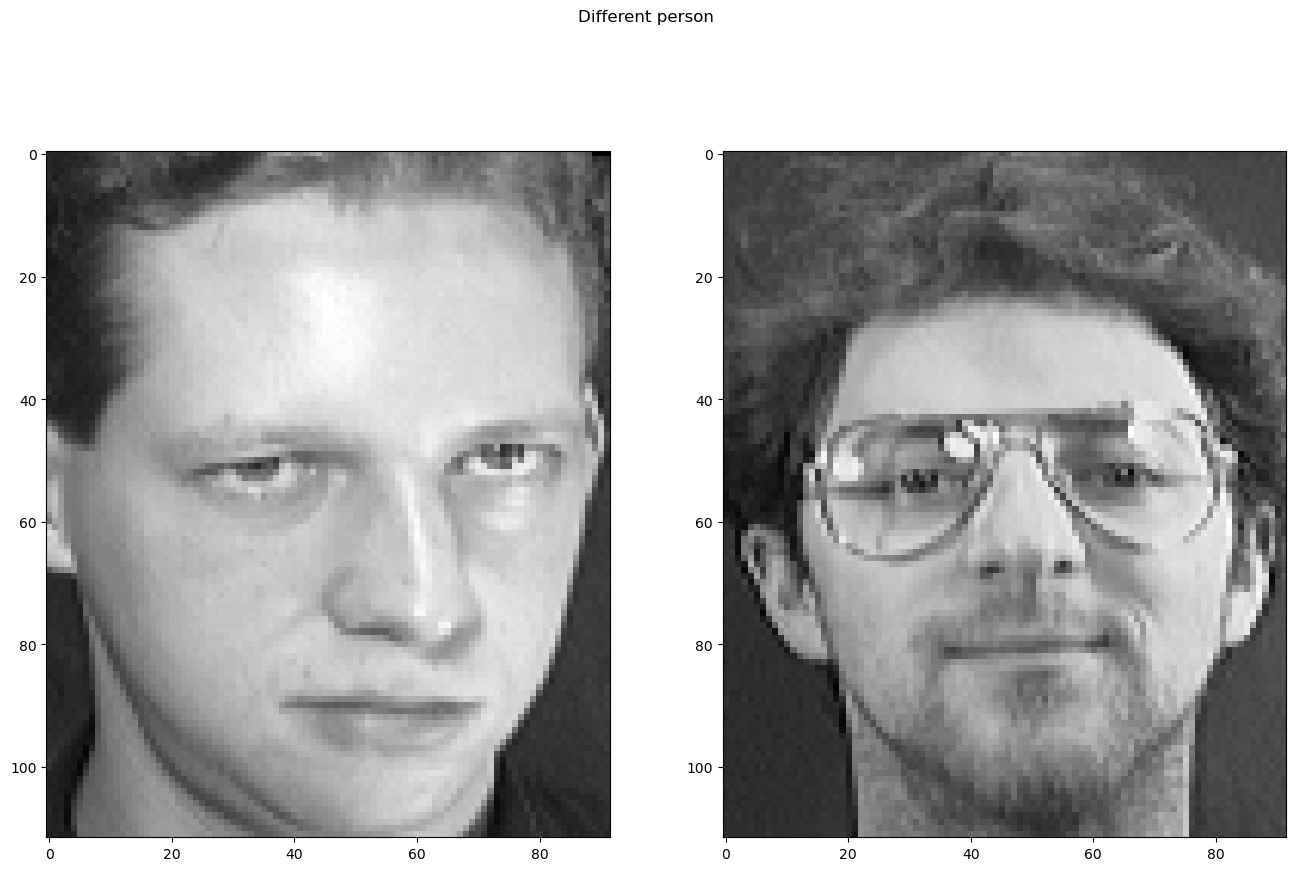

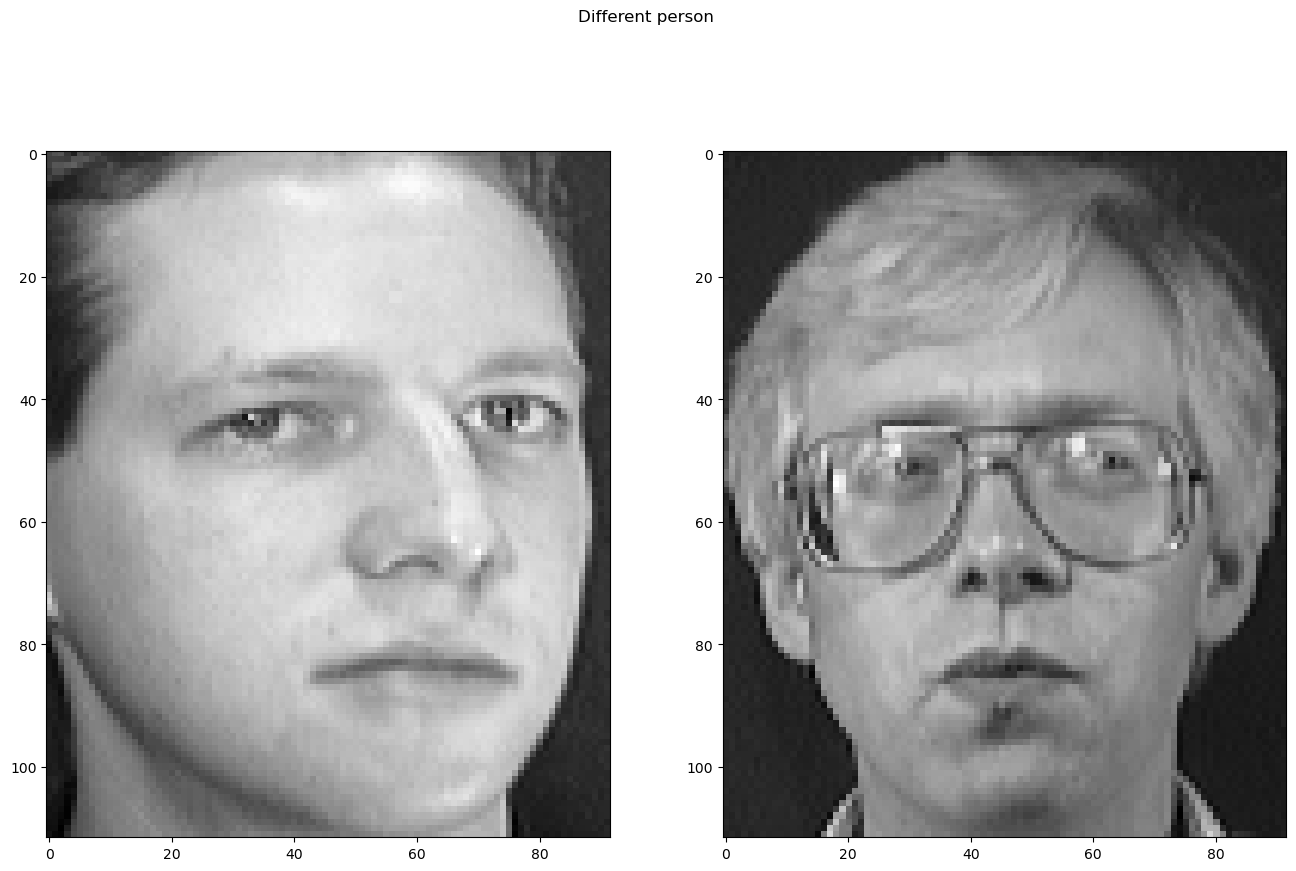

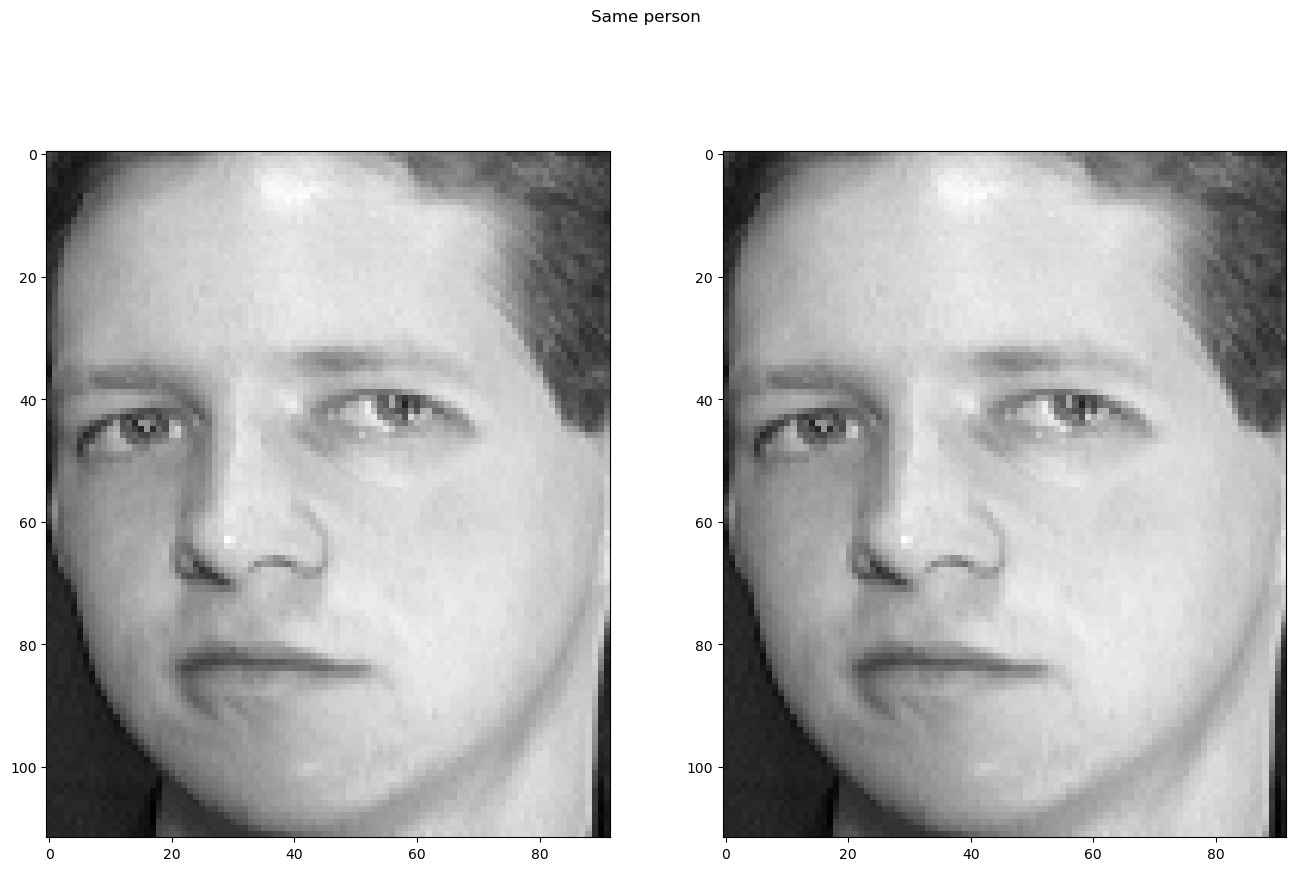

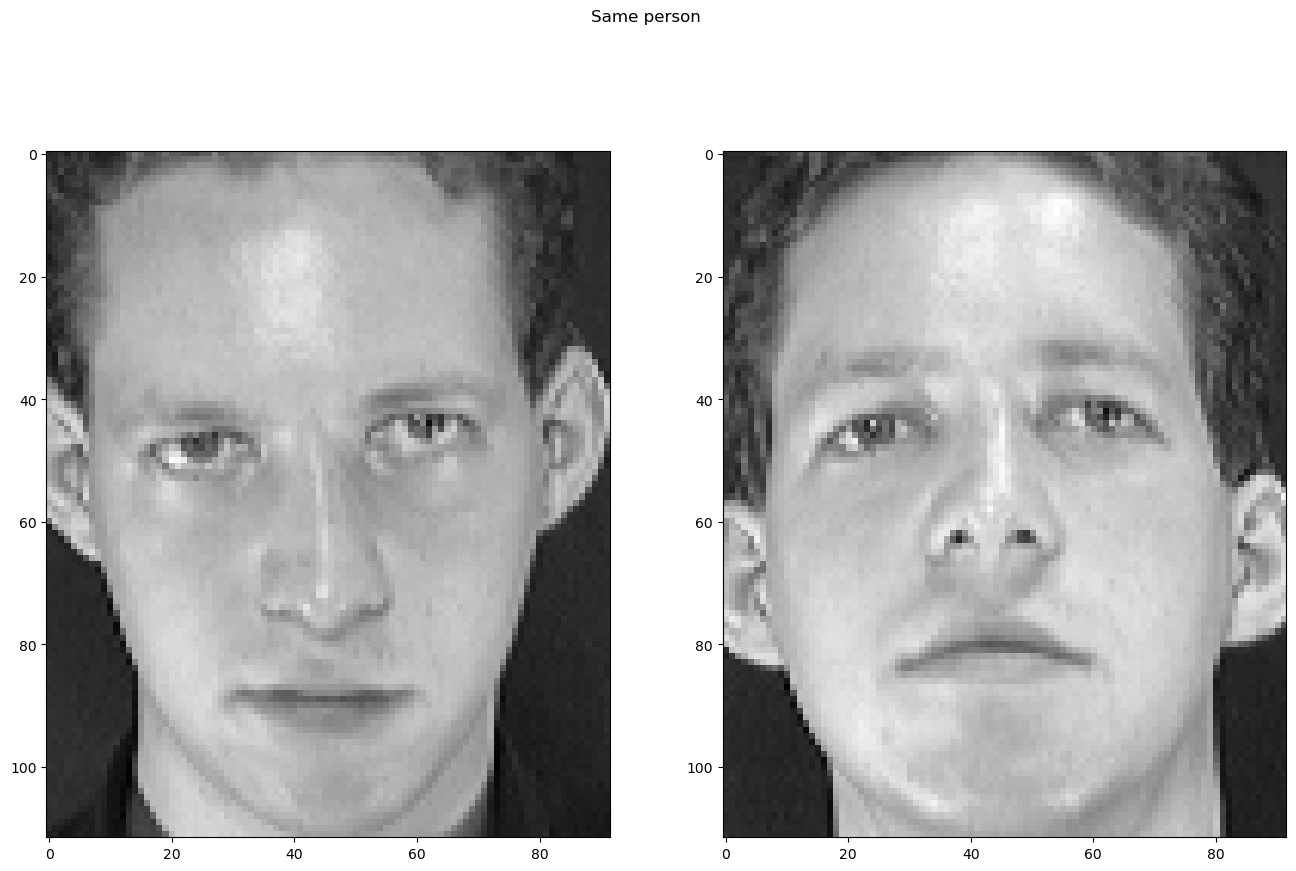

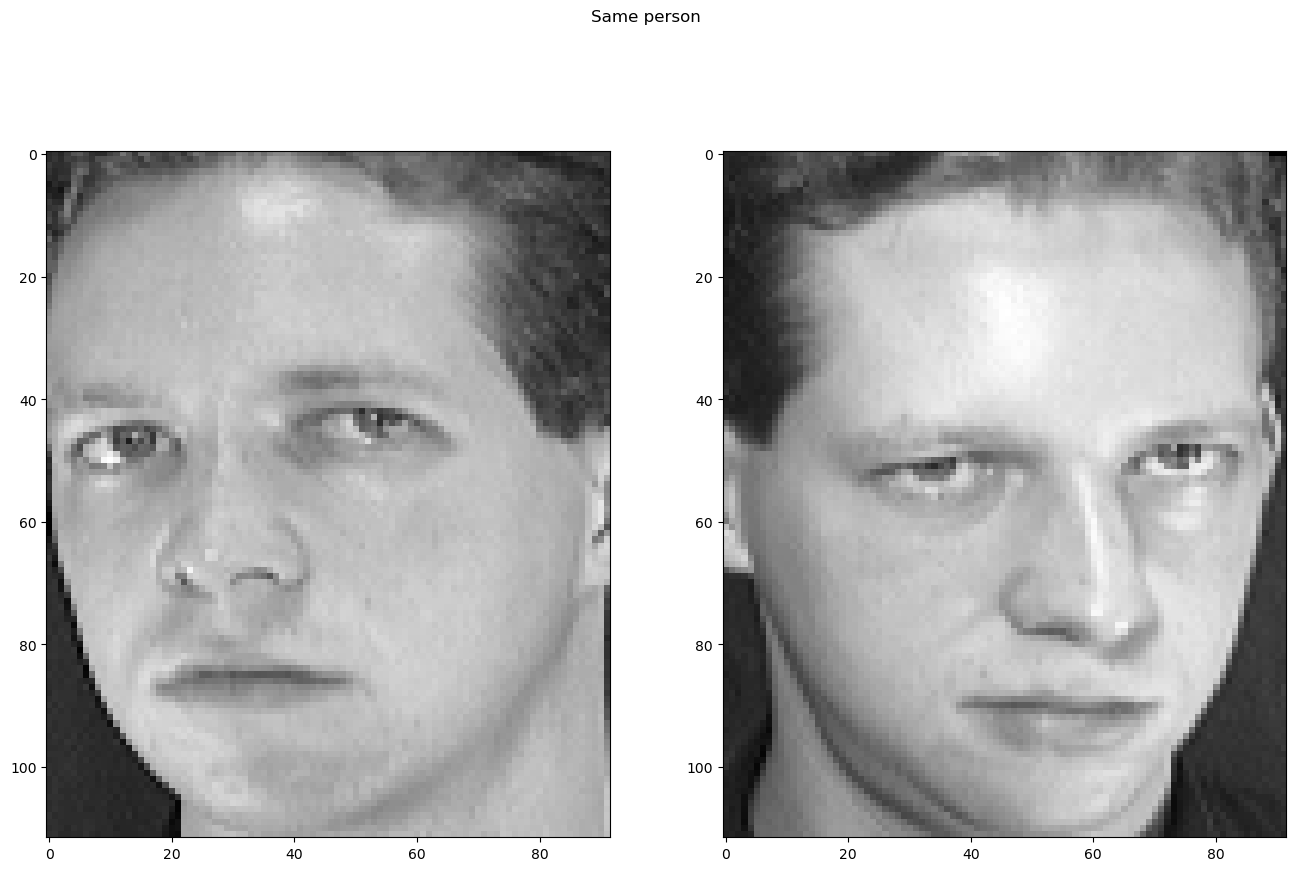

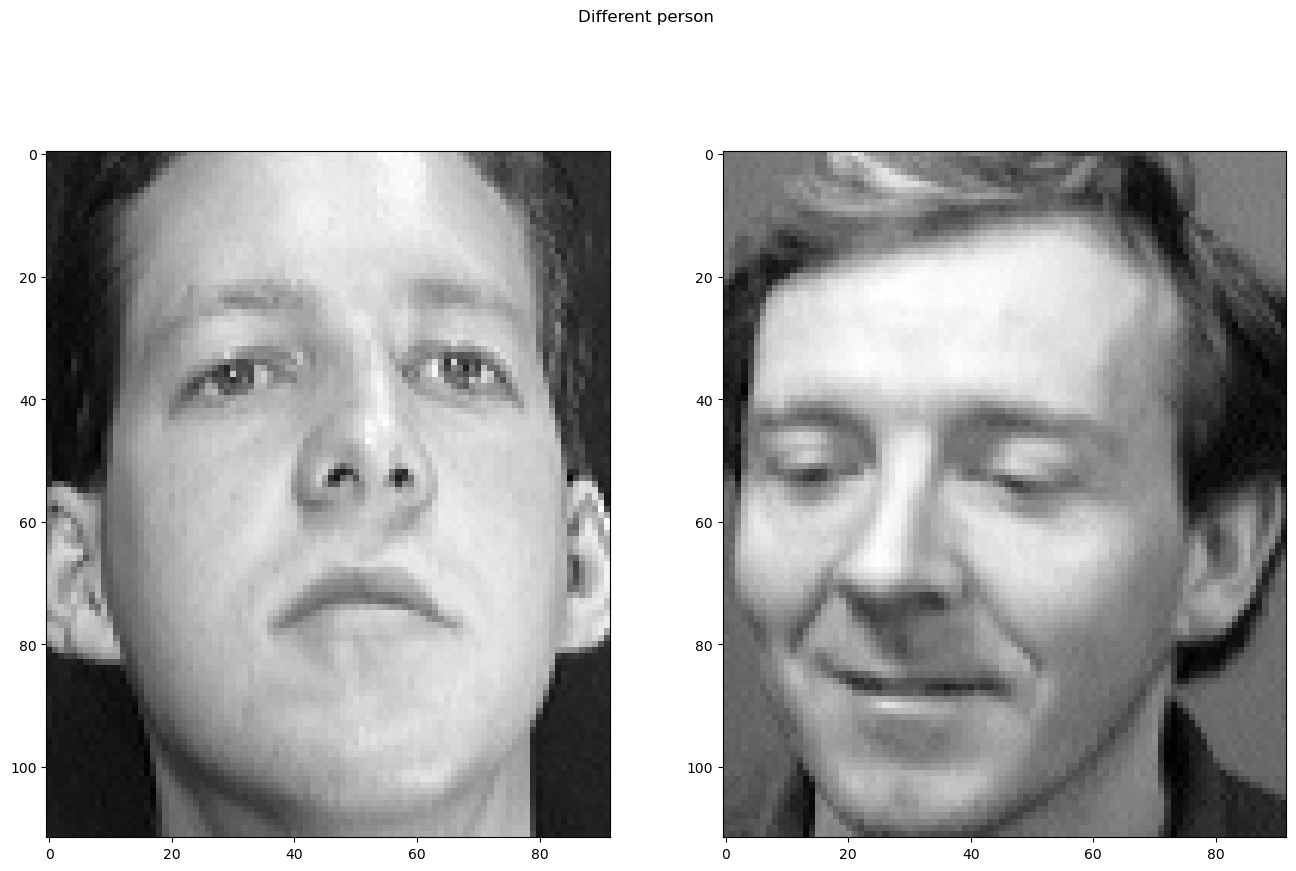

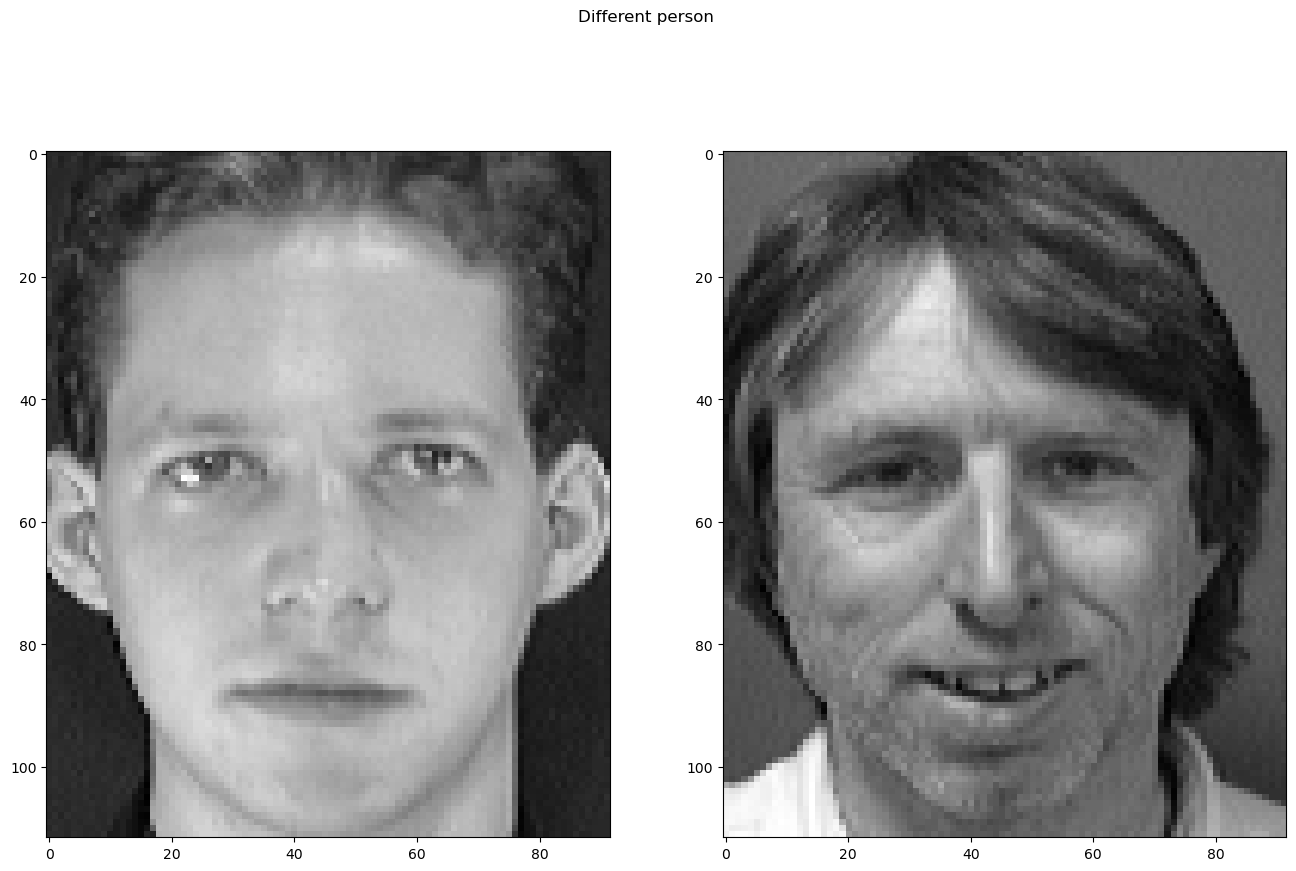

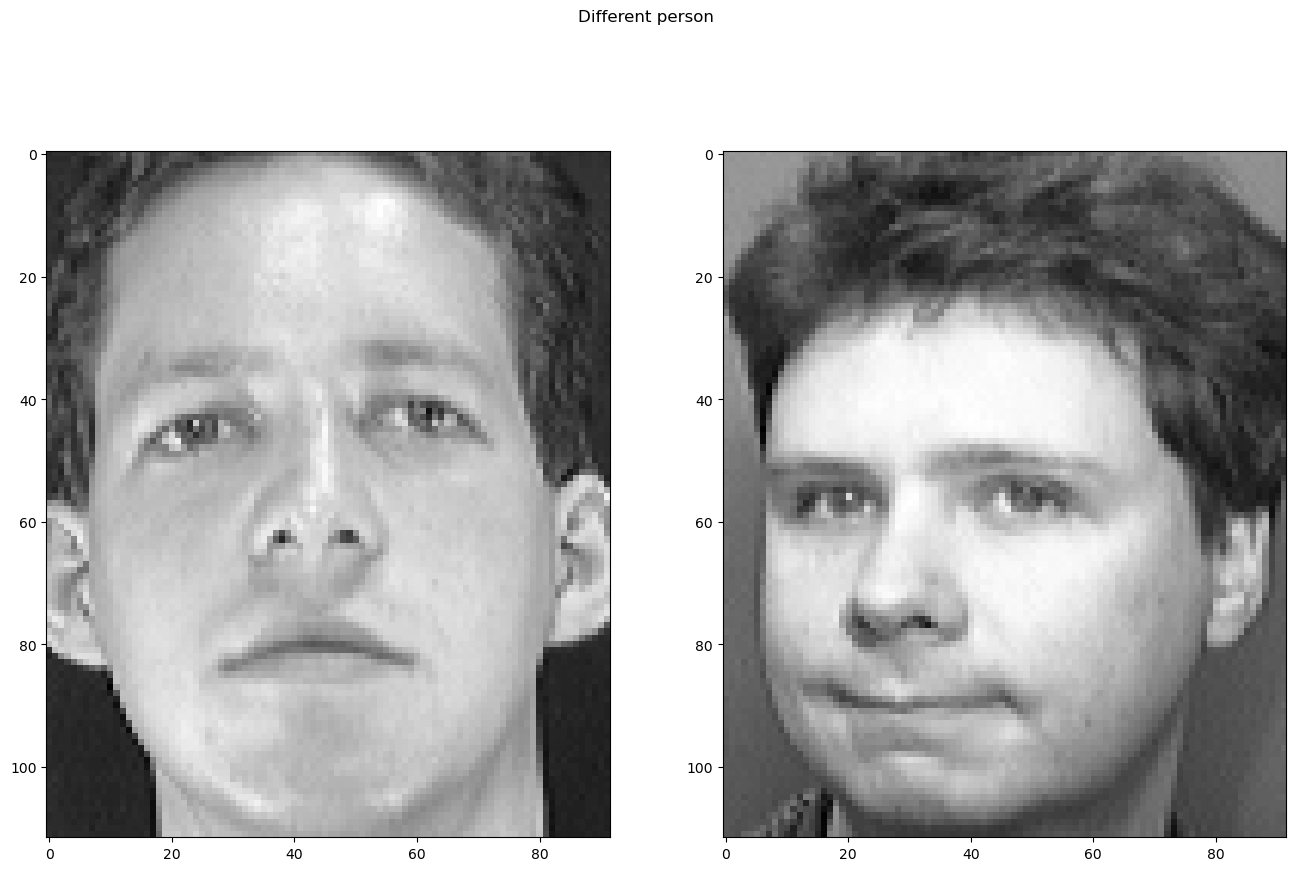

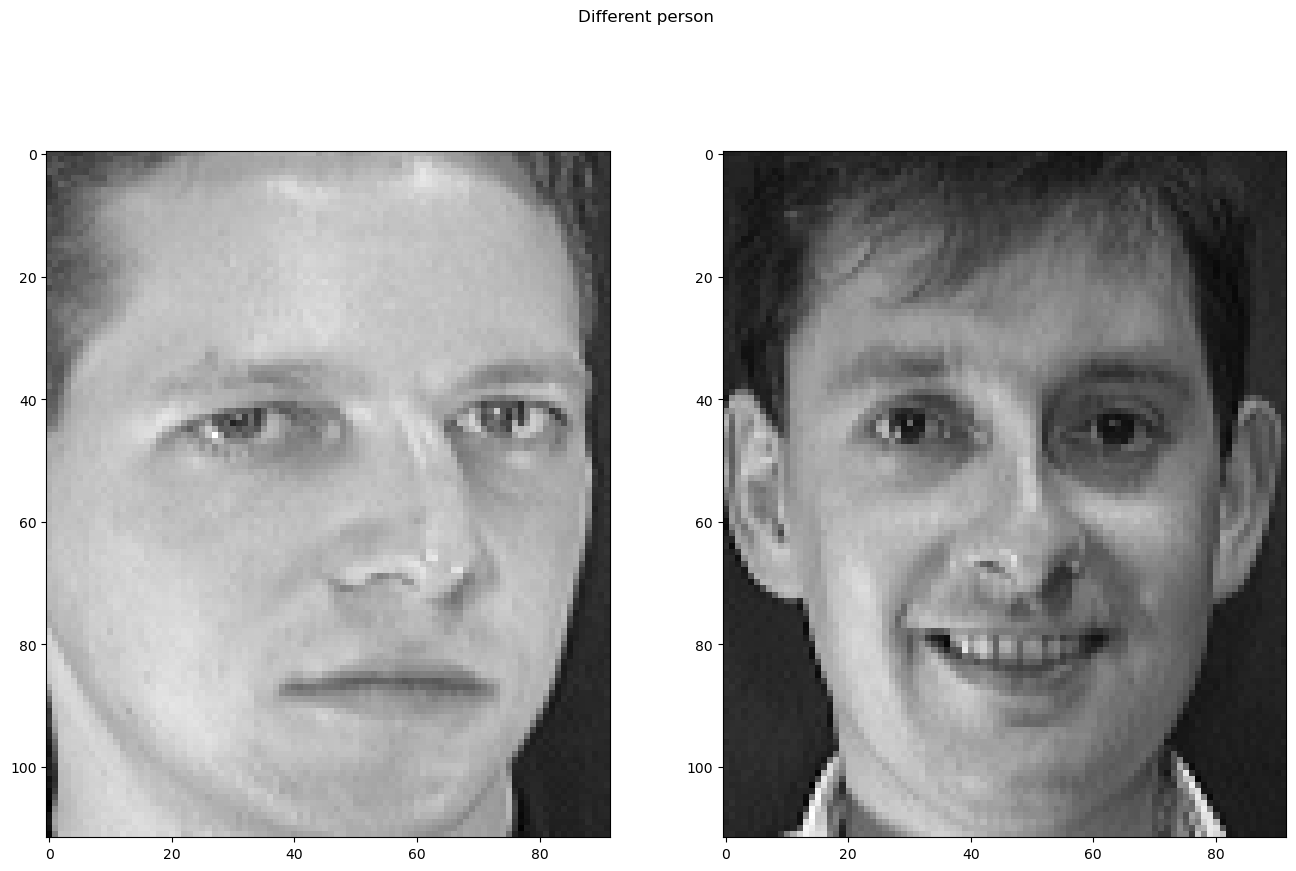

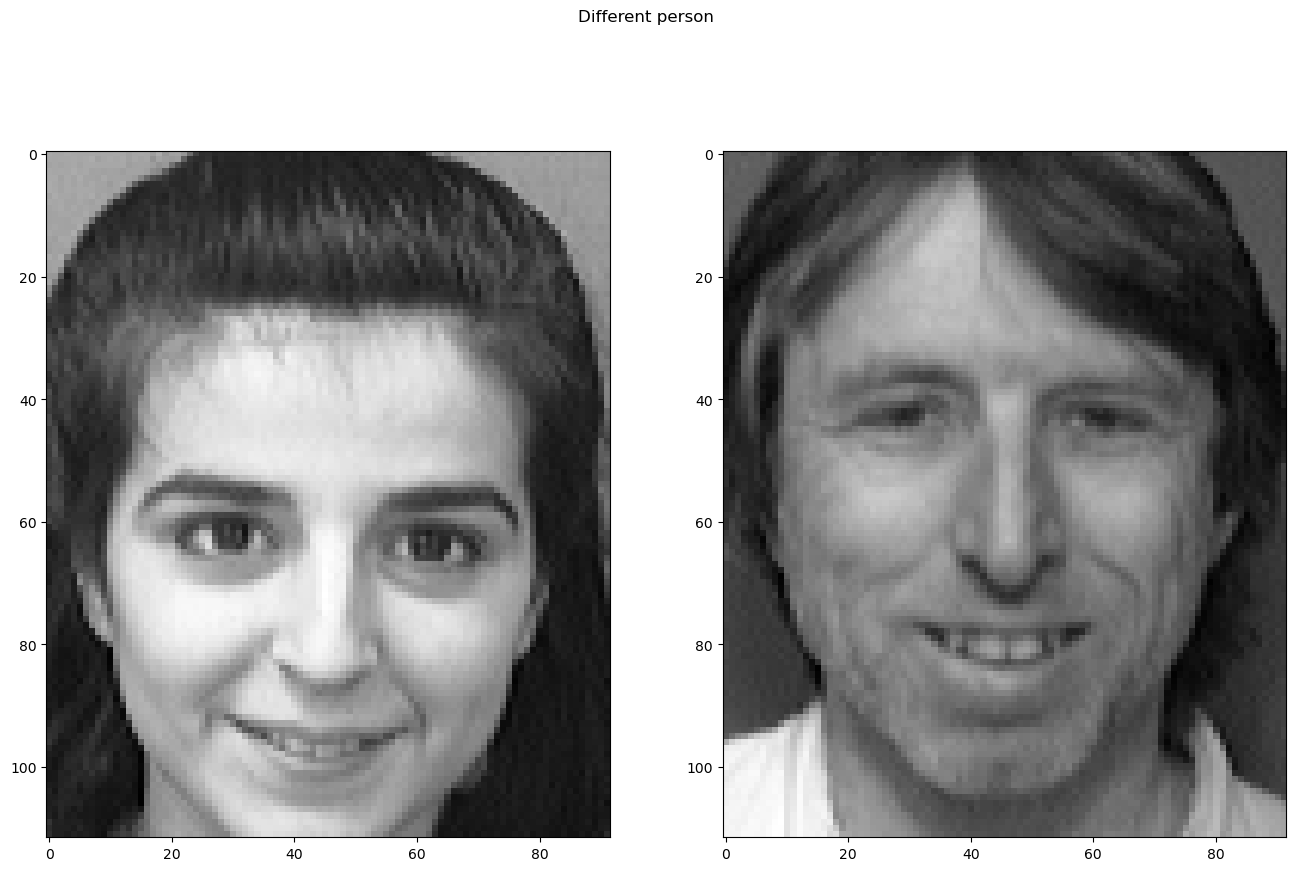

In [39]:
# переберем 10 индексов датасета
for i in range(10):
    fig, ax = plt.subplots(1, 2, figsize = (16, 10))
    img1, img2, label, _ = dataset[i]
    ax[0].imshow(img1, cmap = 'gray')
    ax[1].imshow(img2, cmap = 'gray')

    fig.suptitle('Same person' if label.item() == 1 else 'Different person')
    plt.show()

In [40]:
train_transform = T.Compose(
    [
        T.Resize((128, 128)),
        T.RandomHorizontalFlip(),
        T.ToTensor()
    ]
)

test_transform = T.Compose(
    [
        T.Resize((128, 128)),
        T.ToTensor()
    ]
)

In [41]:
train_dataset = Faces('faces_dataset', split = 'train', transform = train_transform)
valid_dataset = Faces('faces_dataset', split = 'test', transform = test_transform)

In [44]:
train_dataset[0][0].shape

torch.Size([1, 128, 128])

In [73]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 128,
    shuffle = True,
    pin_memory = True
)

test_loader = DataLoader(
    valid_dataset,
    batch_size = 1,
    shuffle = False,
    pin_memory = True
)

len(train_loader)

3

### Напишем свою функцию потерь ContrastiveLoss

In [74]:
class ContrastiveLoss(torch.nn.Module):
    def __init__(self, margin = 2.0):
        super().__init__()
        self.margin = margin

    def forward(self, x1, x2, y):
        # вычисляем евклидово расстояние между векторами
        dist = torch.nn.functional.pairwise_distance(x1, x2, keepdim = True)

        # усредняем лосс по всем батчам
        # если y = 1, будем минимизировать расстояние, если y = 0, будем приближать дистанцию к margin, но делать ее чуть больше
        # расстояние между объктами разных классов должно быть >= margin, между объектами одного класса - минимально 
        return torch.mean(
            y * torch.pow(dist, 2) +
            (1 - y) * torch.pow(torch.clamp(self.margin - dist, min = 0.0), 2)
        )

### Создадим класс модели

In [75]:
class ContrastiveModel(nn.Module):
    def __init__(self):
        super().__init__()

        # получение признаков
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(
                in_channels = 1,
                out_channels = 32,
                kernel_size = 3,
                padding = 1
            ),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),

            nn.MaxPool2d(2), # 128 x 128 -> 64 x 64

            nn.Conv2d(
                in_channels = 32,
                out_channels = 32,
                kernel_size = 3,
                padding = 1
            ),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),

            nn.MaxPool2d(2), # 64 x 64 -> 32 x 32

            nn.Conv2d(
                in_channels = 32,
                out_channels = 32,
                kernel_size = 3,
                padding = 1
            ),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),

            nn.MaxPool2d(2), # 32 x 32 -> 16 x 16

            nn.Flatten()
        )

        # сделаем 2 полносвязных слоя для классификации
        self.fc = nn.Sequential(
            nn.Linear(16 * 16 * 32, 512),
            nn.ReLU(),
            nn.Linear(512, 10) # эмбеддинг из 10 чисел
        )

    # возвращаем эмбеддинг для конкретной картинки
    def forward_single(self, x):
        return self.fc(self.feature_extractor(x))

    # возвращаем эмбеддинги для пары картинок
    def forward(self, x1, x2):
        return self.forward_single(x1), self.forward_single(x2)

In [76]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [93]:
from tqdm import tqdm

def train(model):
    model.train()

    total_loss = 0

    for x1, x2, y, _ in tqdm(train_loader, desc = 'Train'):
        x1 = x1.to(device)
        x2 = x2.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        output1, output2 = model(x1, x2)

        loss = loss_fn(output1, output2, y)

        total_loss += loss.item()
        
        loss.backward()
        
        optimizer.step()
    total_loss /= len(train_loader)
    return total_loss

In [104]:
# напишем функцию для получения картинок в виде тензоров, истинных меток и эмбеддингов

@torch.inference_mode()
def get_latent_base(model):
    model.eval()

    xs = []
    ys = []
    zs = []

    for x, _, _, y in train_loader:
        z = model.forward_single(x)

        xs.append(x) # тензоры
        ys.append(y) # истинные метки
        zs.append(z) # эмбеддинги

    # преобразуем список батчей в тензор
    xs = torch.cat(xs)
    ys = torch.cat(ys)
    zs = torch.cat(zs)

    return xs, ys, zs

@torch.inference_mode()
def evaluate(model):
    model.eval()

    xs, ys, zs = get_latent_base(model)

    total = 0
    correct = 0
    for i, (x, _, _, y) in tqdm(enumerate(test_loader), desc = 'Test'):
        # получаем эмбеддинг изображения
        z = model.forward_single(x)

        # считаем расстояние до всех объектов
        dists = nn.functional.pairwise_distance(z, zs)

        # получаем индекс ближайшего
        idx = torch.argmin(dists)

        # если метка ближайшего и текущего совпали - +1
        correct += (ys[idx].item() == y.item())
        total += 1

    return correct / total

In [95]:
def plot_stats(
    train_loss: list[float],
    test_accuracy: list[float],
    title: str
):
    plt.figure(figsize = (16, 10))
    plt.title(title + ' loss')
    plt.plot(train_loss, label = 'Train loss')
    plt.grid()
    plt.legend()
    plt.show()

    plt.figure(figsize = (16, 10))
    plt.title(title + ' accuracy')
    plt.plot(test_accuracy, label = 'Test accuracy')
    plt.grid()
    plt.legend()
    plt.show()
    

In [96]:
def train_cycle(
    model,
    optimizer,
    loss_fn,
    num_epochs,
    title
):
    train_loss_history, valid_accuracy_history = [], []

    for epoch in range(num_epochs):
        loss = train(model)
        accuracy = evaluate(model)

        train_loss_history.append(loss)
        valid_accuracy_history.append(accuracy)

        lr_shed.step(loss)
        
        clear_output()
        plot_stats(
            train_loss_history,
            valid_accuracy_history,
            title
        )

In [97]:
model = ContrastiveModel().to(device)
optimizer = optim.Adam(model.parameters(), lr = 1e-3)
loss_fn = ContrastiveLoss()

# если loss не изменяется на протяжении 5 эпох - уменьшаем шаг в 2 раза
lr_shed = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor = 0.5, patience = 5)

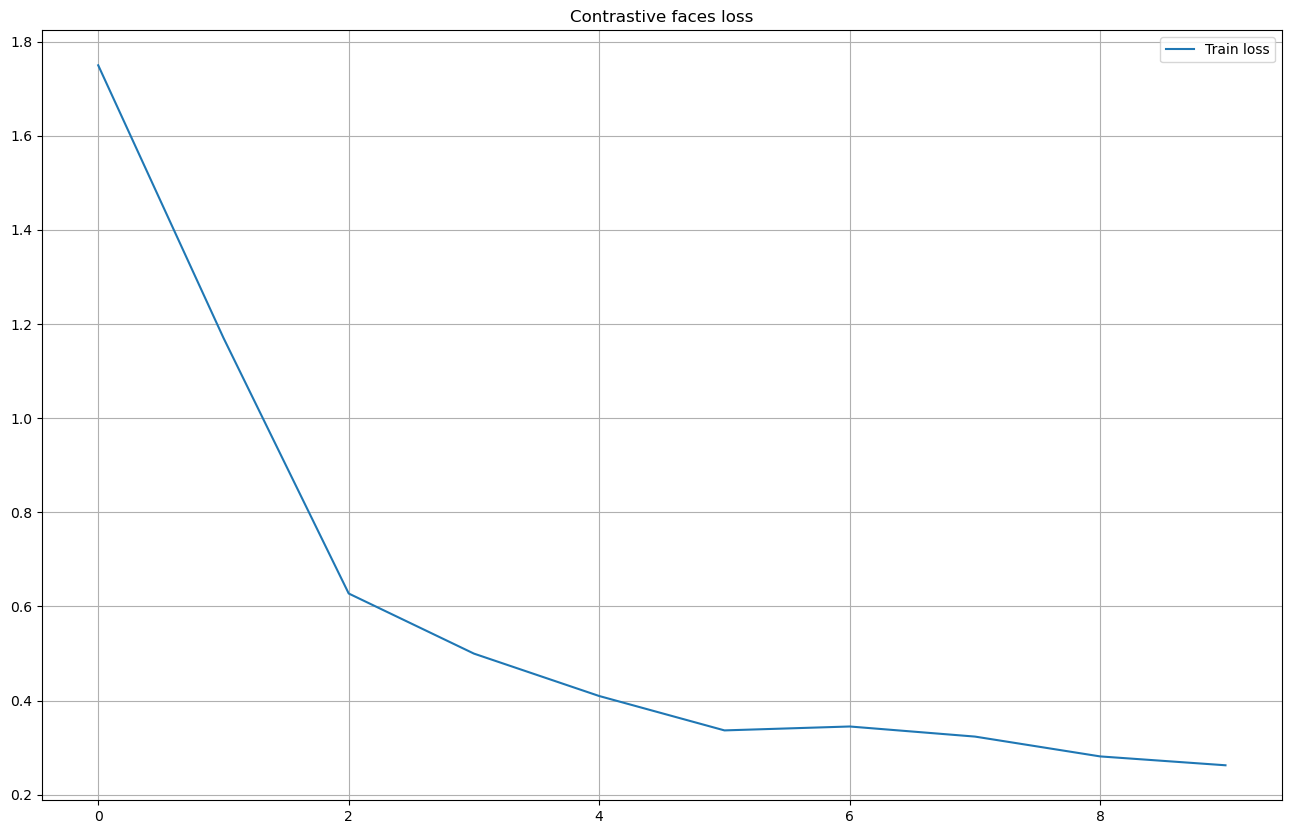

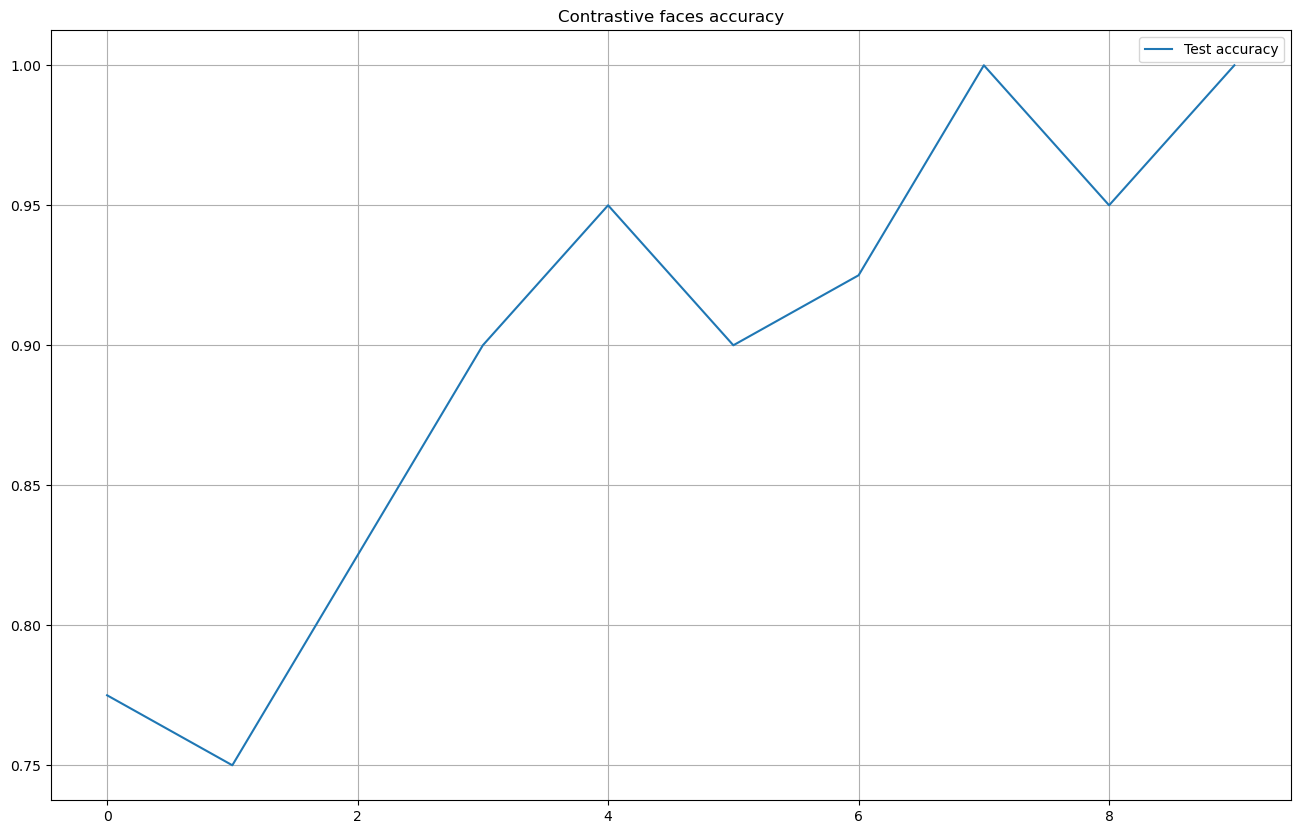

In [98]:
train_cycle(
    model,
    optimizer,
    loss_fn,
    10,
    'Contrastive faces'
)

### Выведем результаты работы

In [99]:
xs, ys, zs = get_latent_base(model)

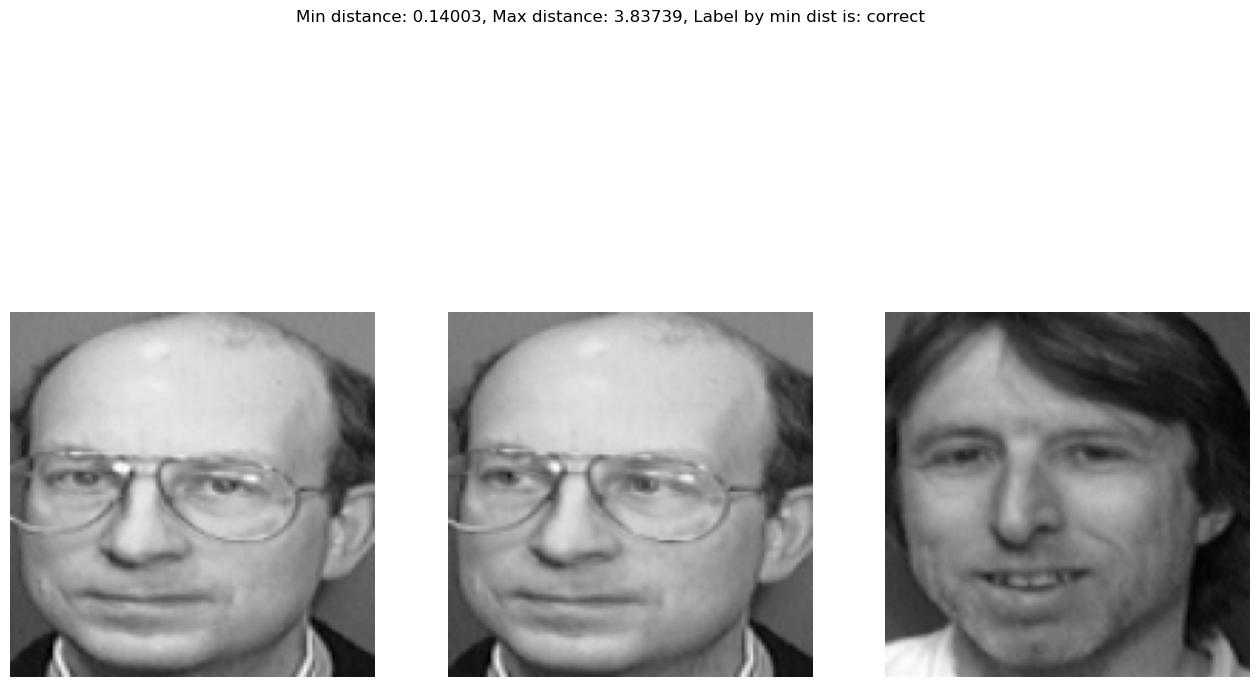

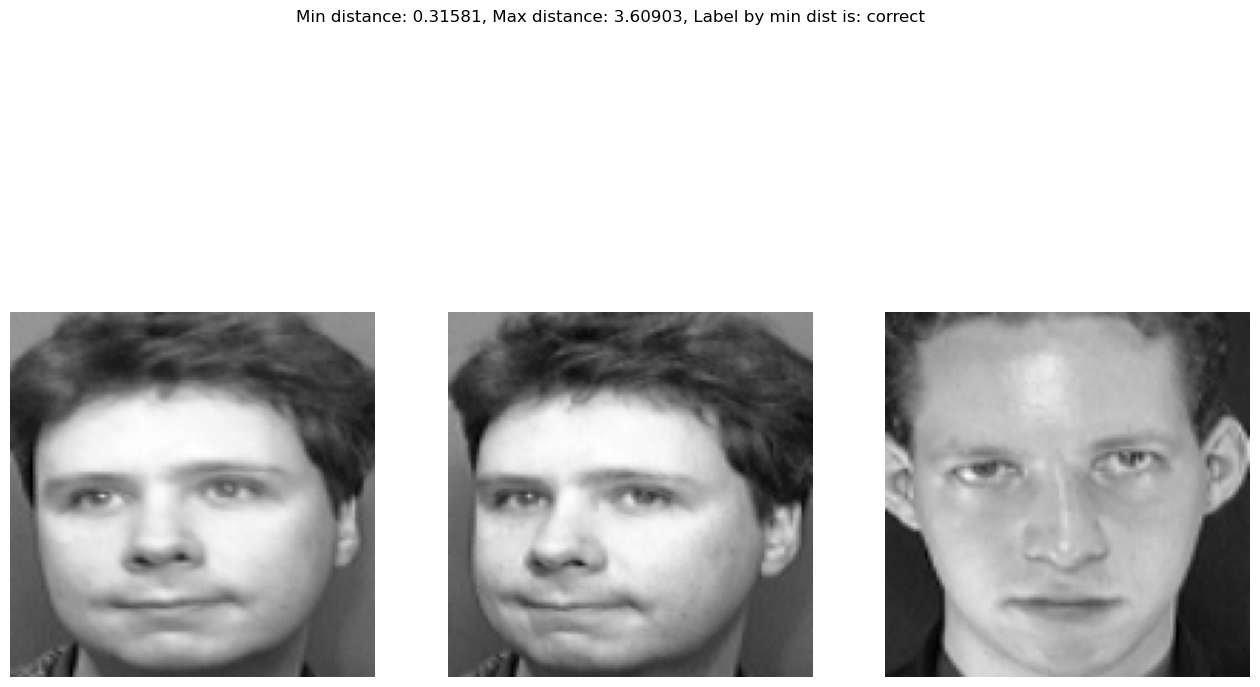

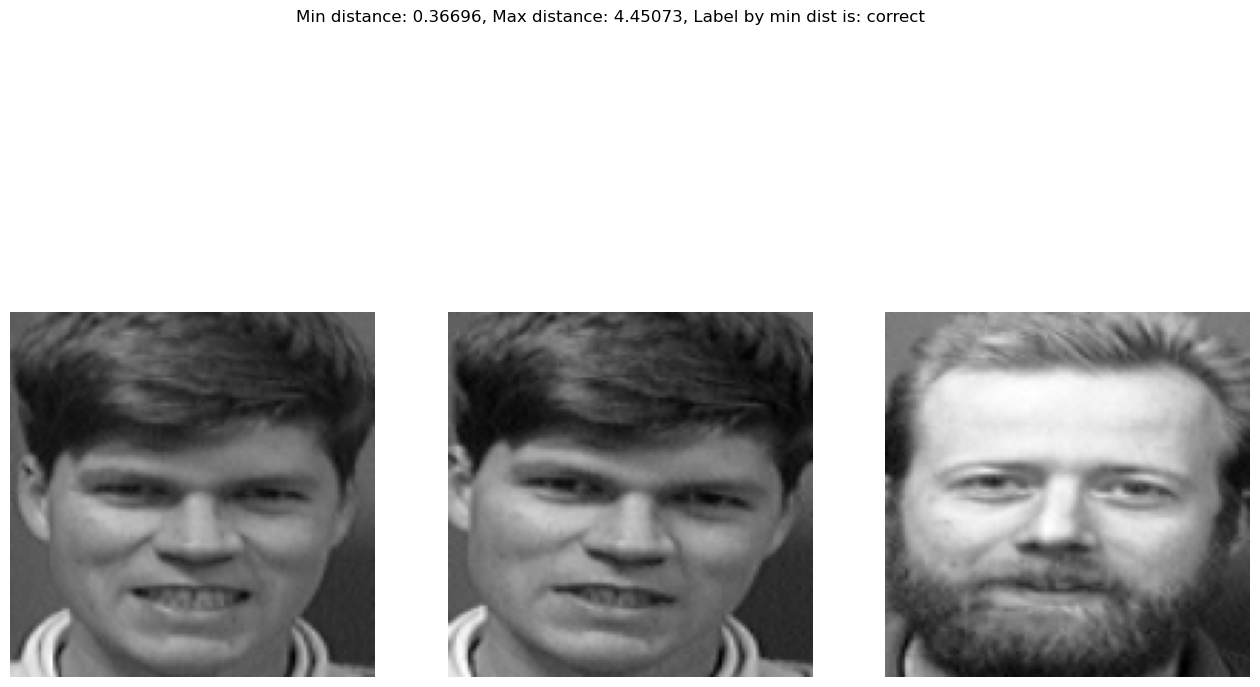

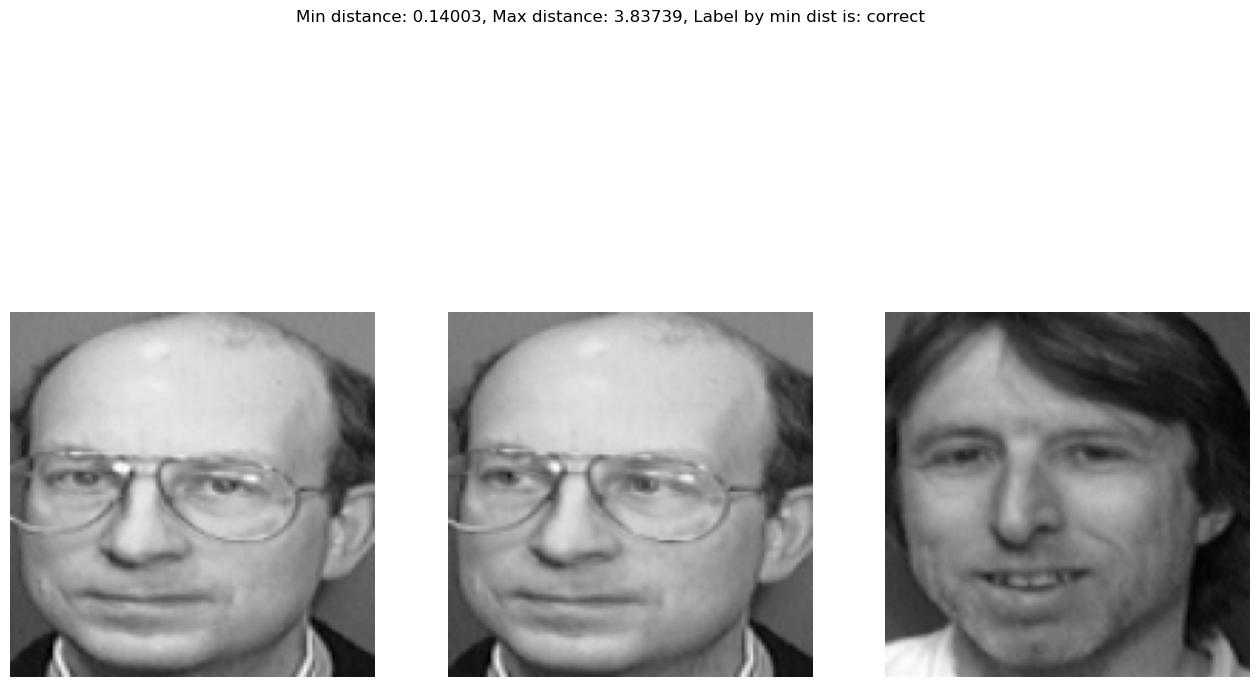

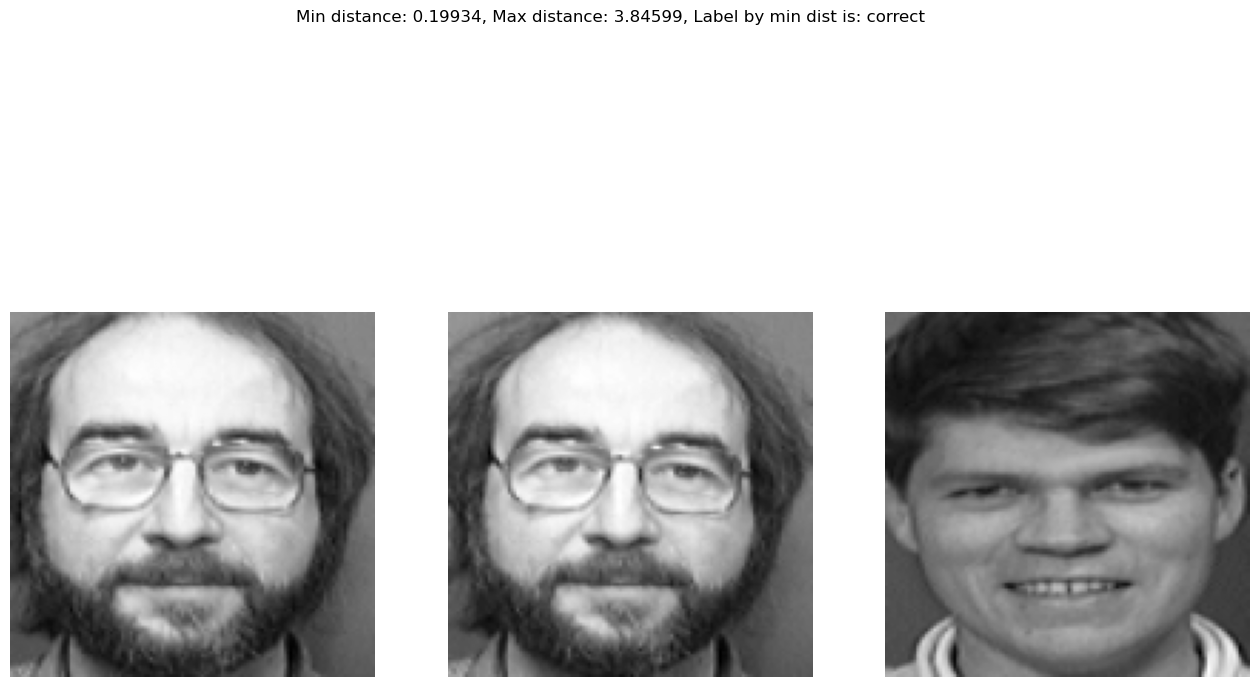

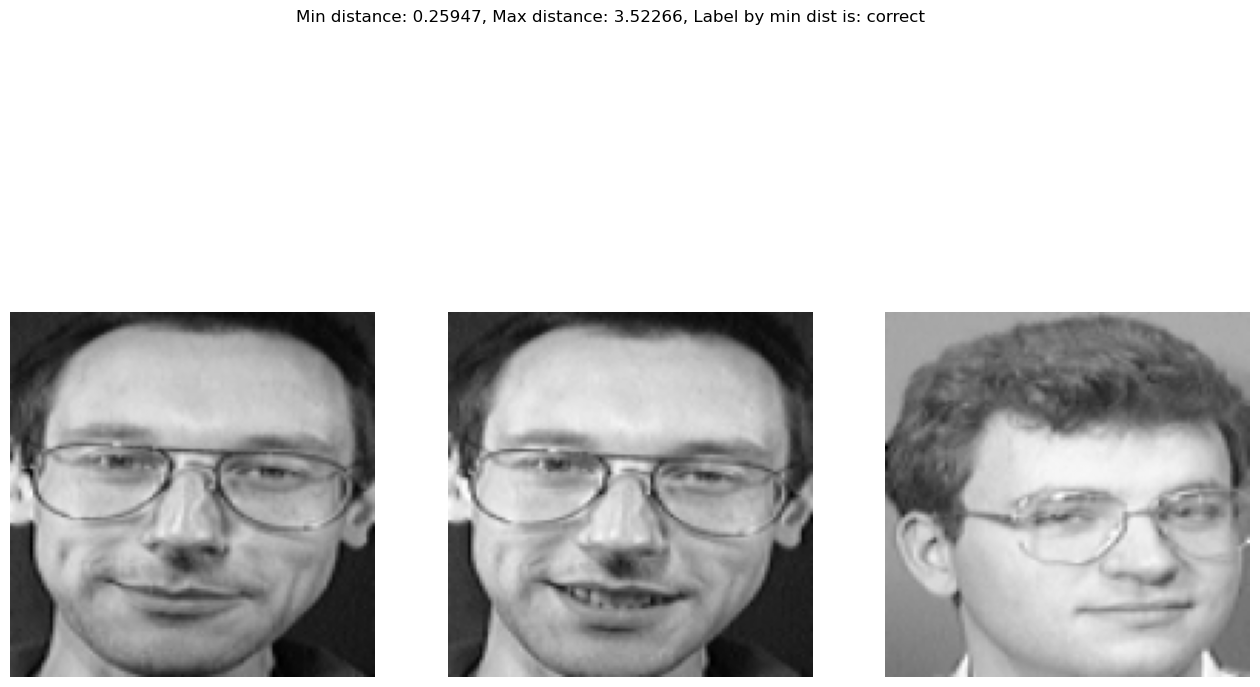

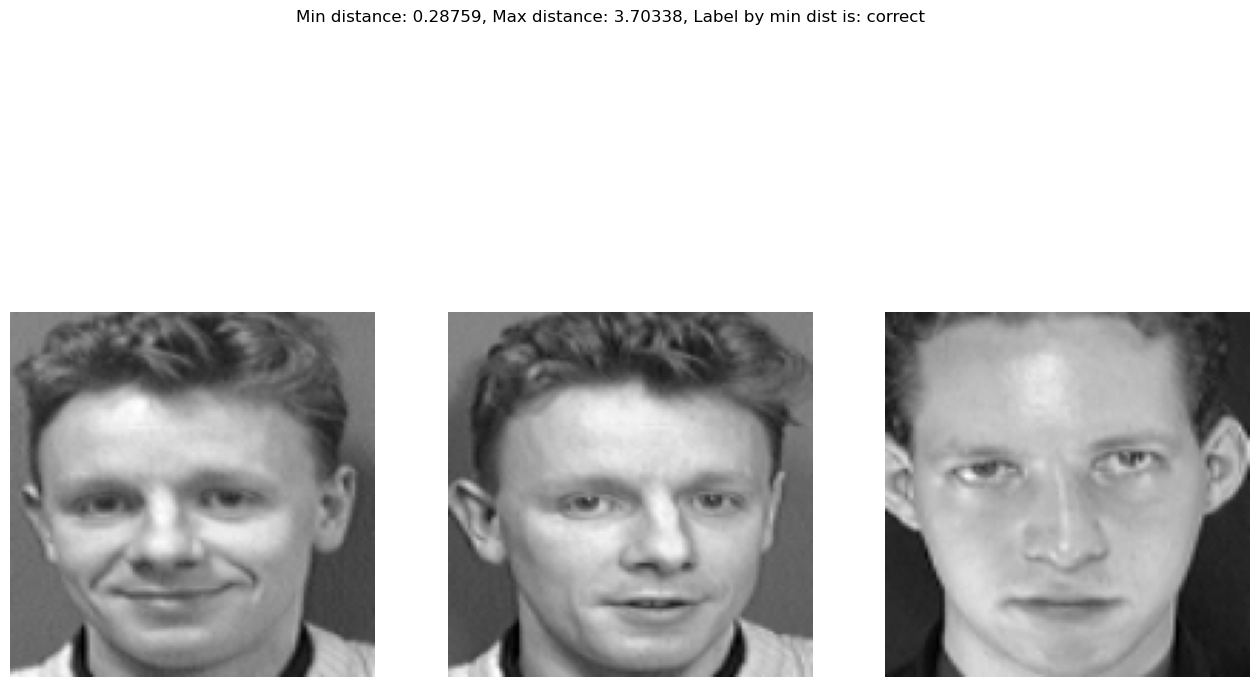

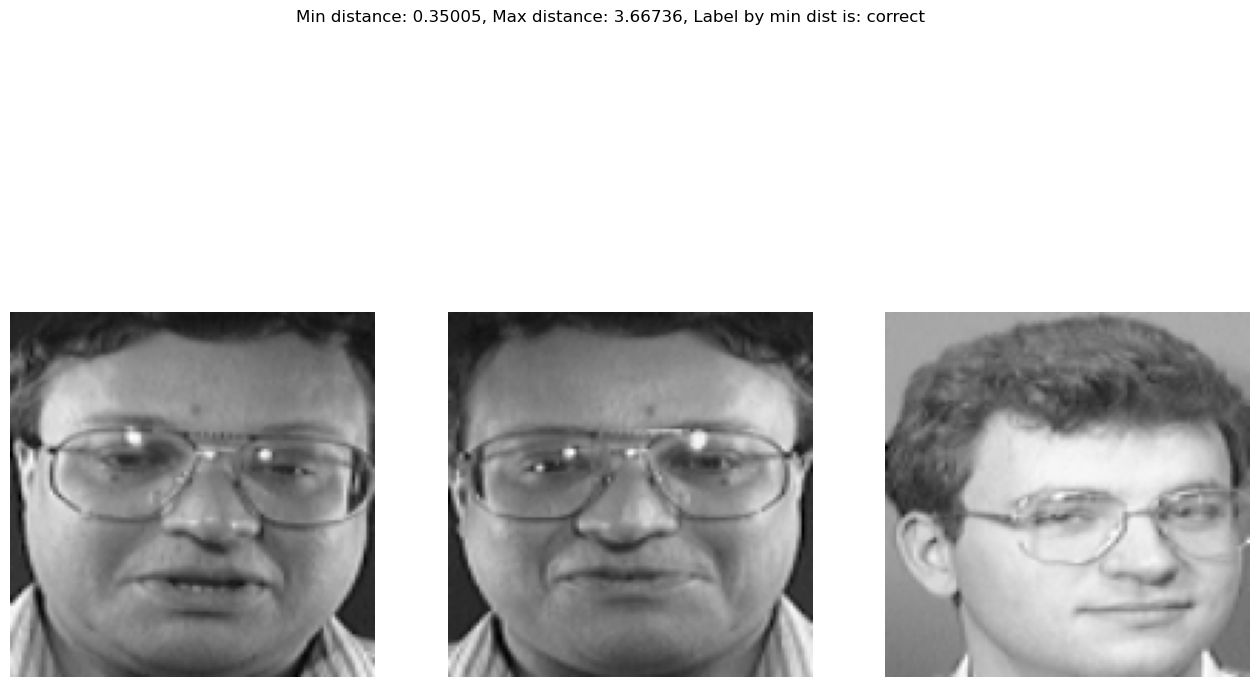

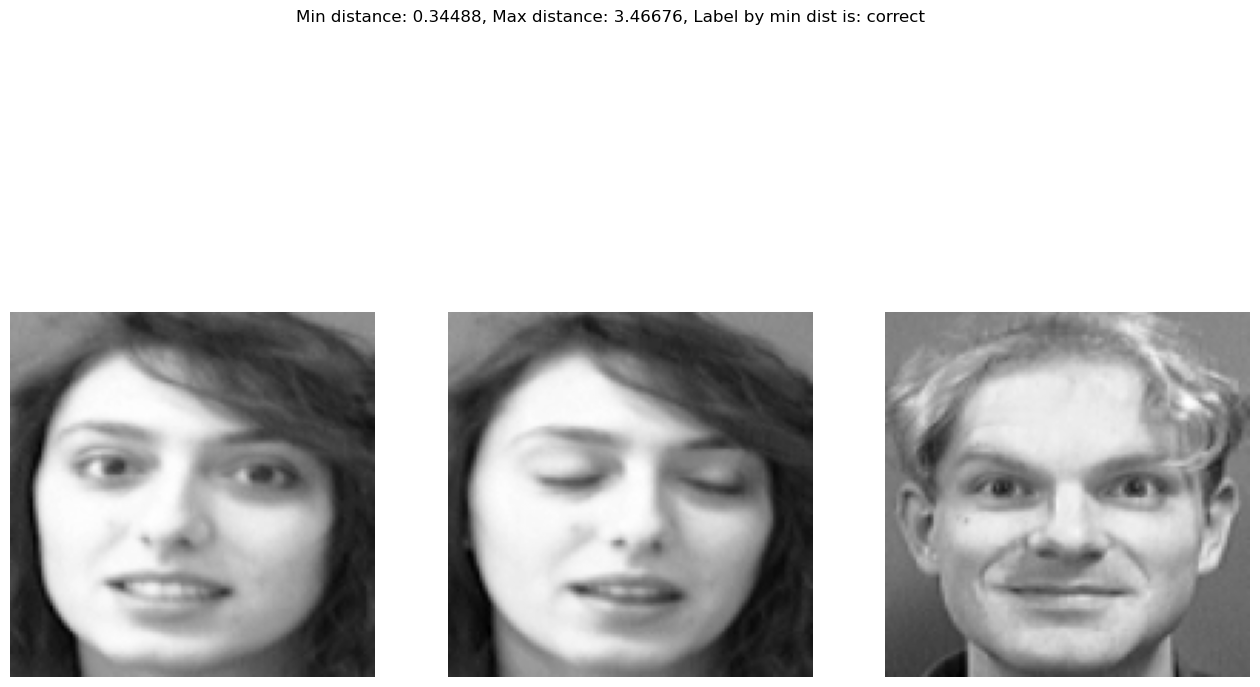

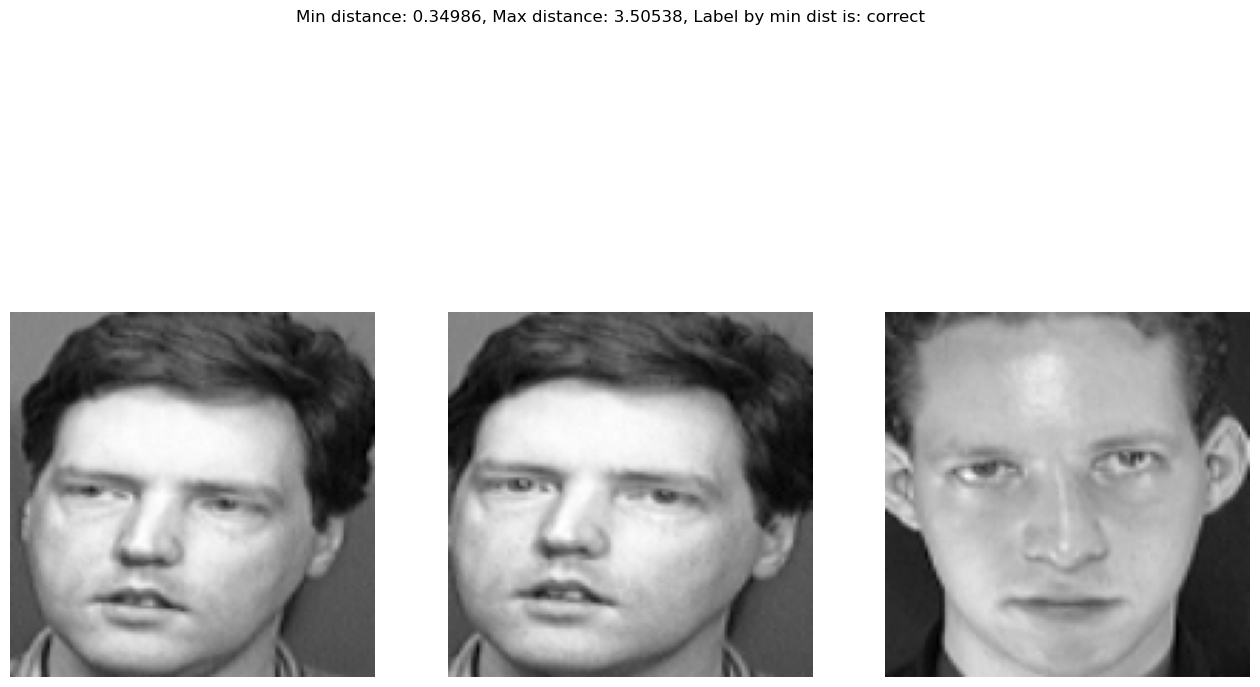

In [106]:
model.eval()

to_pil = T.ToPILImage()

for i in np.random.randint(len(valid_dataset), size = 10):
    x, _, _, label = valid_dataset[i]

    with torch.inference_mode():
        z = model.forward_single(x.unsqueeze(0).to(device))

    dists = nn.functional.pairwise_distance(z, zs)

    closest_idx = np.argmin(dists)
    farest_idx = np.argmax(dists)

    fig, ax = plt.subplots(1, 3, figsize = (16, 10))

    ax[0].imshow(to_pil(x), cmap = 'gray')
    ax[1].imshow(to_pil(xs[closest_idx]), cmap = 'gray')
    ax[2].imshow(to_pil(xs[farest_idx]), cmap = 'gray')

    ax[0].axis('off')
    ax[1].axis('off')
    ax[2].axis('off')
    
    plt.suptitle(f'Min distance: {dists[closest_idx].item():.5f}, Max distance: {dists[farest_idx].item():.5f}, Label by min dist is: {'correct' if ys[closest_idx].item() == label.item() else 'incorrect'}')
    plt.show()
    